# VOCALS-REx retrieval with pydisort_riccati_jax

The ultimate goal is to **retrieve an effective-radius profile $r_e(\tau)$** from VOCALS-REx marine stratocumulus, using the fully differentiable chain

$$ r_e(\tau)\xrightarrow{\;\texttt{miejax\_lite}\;}\big(\omega(\tau),\,\text{Leg\_coeffs}(\tau)\big)\xrightarrow{\;\texttt{pydisort\_riccati\_jax}\;} u^{+}(\tau{=}0,\mu,\phi). $$

VOCALS stratocumulus has $r_e\approx 4$–$17\,\mu\mathrm{m}$, observed in the MODIS bands 0.645 / 1.64 / **2.13** µm (2.13 µm is the most absorbing, where $\omega<1$ carries the size signal), with $\tau$ up to $\sim30$ over a low-albedo ocean ($\rho\approx0.06$). This notebook assumes the [intro notebook](./riccati_solver_intro.ipynb) and that [`miejax_lite`](../../miejax_lite/README.md) is installed (`pip install -e ../miejax_lite`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from math import pi

from pydisort_riccati_jax import pydisort_riccati_jax, interpolate
from miejax_lite import (
    mie_legendre_precompute, build_re_table, select_channel, table_lookup,
)

## 1. Mie optical properties from $r_e(\tau)$

We model an **adiabatic** cloud whose effective radius grows from cloud base ($\tau{=}$ `tau_bot`) toward top. The optics come from a **precomputed $r_e\to(\omega,\text{Leg\_coeffs})$ interpolation table** (`build_re_table` / `table_lookup`): full Mie inside the solver's ODE never finishes compiling, so we tabulate it once over the physical size range and do an $O(1)$, differentiable linear lookup in the hot path. The table is built at high radius-integration resolution for a ripple-free map, over a grid $[2,25]\,\mu$m spanning the VOCALS-REx in-cloud $r_e$ range with margin (design: [`optics_table_map.md`](../../miejax_lite/docs/optics_table_map.md)). We wrap the lookup in the `*_func(tau)` callables the solver expects.

The profile is written so that $r_e^5$ is **linear** in optical depth. The adiabatic law *in optical depth* is $r_e\propto\tau^{1/5}$: $r_e^3\propto\,$LWC versus *geometric height* ($\mathrm{LWC}\propto z$), but the extinction $\beta\propto r_e^2\propto z^{2/3}$ makes $\tau=\int\!\beta\,dz\propto z^{5/3}$, so $\mathrm{LWC}\propto\tau^{3/5}$ and $r_e\propto\tau^{1/5}$ (equivalently the canonical adiabatic $N_d\propto\tau^{1/2}r_e^{-5/2}$). Making $r_e^5$ affine in $\tau$ keeps $r_e\ge r_\text{base}$ with $dr_e/d\tau$ finite — the textbook $r_e\propto(1-\tau/\tau_\text{bot})^{1/5}$ has an infinite-slope root cusp at cloud base that exhausts the adaptive ODE solver (real VOCALS-REx profiles are finite-slope).

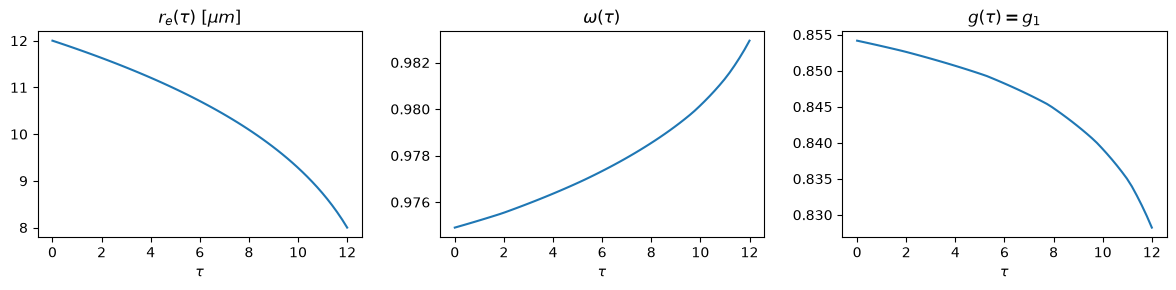

In [2]:
wavelength, v_eff = 2.13, 0.10           # MODIS band 7 (microns), gamma width

tau_bot = 12.0
NQuad, NLeg, NLeg_all = 16, 16, 32       # streams; NLeg_all > NLeg feeds delta-M / TMS
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)

# Optics interpolation table r_e -> (omega, Leg_coeffs), built once (offline,
# high n_radii -> ripple-free). Full Mie inside the ODE never finishes compiling;
# the table makes the optics O(1) and keeps r_e -> (omega, Leg) differentiable
# (table-slope Jacobian). select_channel picks the (single) MODIS band exactly.
opt = select_channel(
    build_re_table([wavelength], 2.0, 25.0, 32, v_eff, precomp, n_radii=600), 0)

# Adiabatic r_e(tau): grows from base (tau=tau_bot) to top (tau=0). The adiabatic
# law in OPTICAL DEPTH is r_e ~ tau^(1/5): r_e**3 ~ LWC ~ height z, but the
# extinction ~ r_e**2 makes tau ~ z^(5/3), so r_e ~ tau^(1/5). We make r_e**5 affine
# in tau -> r_e stays >= re_base and dr_e/dtau is finite (no root cusp at base).
re_top, re_base = 12.0, 8.0              # microns (marine Sc: gentle 12->8 um growth)
def r_e_of_tau(tau, re_top=re_top, re_base=re_base):
    return (re_base ** 5 + (re_top ** 5 - re_base ** 5) * (1 - tau / tau_bot)) ** (1 / 5)

def optics(tau, re_top=re_top, re_base=re_base):
    return table_lookup(opt, r_e_of_tau(tau, re_top, re_base))

omega_func      = lambda tau: optics(tau)[0]
Leg_coeffs_func = lambda tau: optics(tau)[1]

tau_plot = jnp.linspace(0, tau_bot, 60)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(tau_plot, [r_e_of_tau(t) for t in tau_plot]); ax[0].set_title(r'$r_e(\tau)\ [\mu m]$')
ax[1].plot(tau_plot, [omega_func(t) for t in tau_plot]); ax[1].set_title(r'$\omega(\tau)$')
ax[2].plot(tau_plot, [Leg_coeffs_func(t)[1] for t in tau_plot]); ax[2].set_title(r'$g(\tau)=g_1$')
for a in ax: a.set_xlabel(r'$\tau$')
plt.tight_layout()

## 2. Forward model: ToA radiance

Solve, then interpolate to the satellite viewing geometry. This `forward` function — radiance as a function of the profile parameters — is the object we will both evaluate and differentiate.

In [3]:
mu0, I0, phi0 = 0.6, 1.0, 0.0           # solar geometry
mu_obs, phi_obs = 0.5, pi               # viewing geometry
BDRF = [0.06]                       # ocean surface

def forward(re_top, re_base):
    om  = lambda tau: optics(tau, re_top, re_base)[0]
    Leg = lambda tau: optics(tau, re_top, re_base)[1]
    mu_arr_pos, flux_up, u0, u_func, _ = pydisort_riccati_jax(
        tau_bot, om, Leg, NQuad, mu0, I0, phi0,
        tol=1e-3, BDRF_Fourier_modes=BDRF,                    # float32-safe production tol
        delta_M_scaling=True, NLeg_all=NLeg_all, NT_cor=True)  # forward-peak fix (OUTSTANDING A)
    return interpolate(u_func, mu_arr_pos)(mu_obs, phi_obs)

I_obs = forward(re_top, re_base)
print('ToA radiance at (mu_obs, phi_obs):', float(I_obs))

ToA radiance at (mu_obs, phi_obs): 0.27201661467552185


## 3. Retrieval Jacobian via autodiff

Because the whole chain is JAX-traceable, the sensitivity of the observed radiance to the profile parameters is a single `jax.grad` — no finite differences, no perturbing the solver. This $\partial I/\partial r_e$ is the building block of the retrieval's Gauss–Newton / optimal-estimation step.

*Parameters must enter through `omega_func`/`Leg_coeffs_func`; `tau_bot`, `mu0`, `NQuad` are validated in NumPy and are not differentiable. Finite-difference validation of these gradients lives in the float64 test suite (`pytest -m float64`); in float32 a bare FD is dominated by the solver's tolerance floor, so we don't reproduce it in this demonstration.*

In [4]:
dI_dre_top, dI_dre_base = jax.grad(forward, argnums=(0, 1))(re_top, re_base)
print('dI/d(r_e top)  =', float(dI_dre_top))
print('dI/d(r_e base) =', float(dI_dre_base))

dI/d(r_e top)  = 0.015191251412034035
dI/d(r_e base) = -0.0002068690664600581


## 4. Toward a multi-band retrieval

A real retrieval stacks several MODIS bands (0.645 µm constrains $\tau$, 2.13 µm constrains $r_e$) and minimises a cost $\;J(\boldsymbol\theta)=\sum_b \lVert I_b^{\text{obs}}-F_b(\boldsymbol\theta)\rVert^2 + \text{(prior)}$ over the $r_e(\tau)$ parameters $\boldsymbol\theta$.
 The gradient $\nabla_{\boldsymbol\theta} J$ is assembled from the per-band Jacobians above via `jax.grad`, and fed to an optimiser (`jaxopt`, `optax`, or a hand-rolled Gauss–Newton step). Stacking bands is just building the table at several wavelengths — `build_re_table([0.645, 1.64, 2.13], …)` and `select_channel` per band; a hyperspectral instrument instead builds on a dense, uniform $\lambda$ grid and `slice_wavelength`-interpolates to each channel.

**Performance & scope notes.** The forward model's cost is dominated by the number of adaptive Riccati steps (~35 for $\tau{=}30$); loosen `tol` in the retrieval loop and tighten only for the final fit. The default float32 is adequate against VOCALS measurement noise (10–20 %); enable `jax_enable_x64` for finite-difference gradient checks. Delta-M scaling + the Nakajima–Tanaka TMS correction are **enabled here** (`delta_M_scaling=True, NT_cor=True`, with `NLeg_all=32` untruncated moments) so the forward-peaked-Mie ToA radiance stays non-negative (see [`OUTSTANDING.md`](./OUTSTANDING.md) §A); the reverse-mode Jacobian is exact AD, its memory now bounded by the `lax.scan` over Fourier modes (§H).

## 5. A real VOCALS-REx profile + a leak-free prior (the joint retrieval)

We retrieve $r_e(\tau)$ from a genuine VOCALS-REx marine-stratocumulus
penetration. `vocals_io` reads a C-130 flight (CDP probe, 1 Hz), finds clean
in-cloud profiles, and returns each as $(\tau, r_e)$ with the cloud-optical-depth
integration $\tau(z)=\pi\!\int Q_{\rm ext}\, r_e^2 N_c\,dz$ from cloud top down.

**This is now a *joint* retrieval.** The earlier version fixed the cloud base
$(\tau_{\rm bot},\,r_e(\tau_{\rm bot}))$ from the truth — a threefold information
leak (optical thickness, base radius, *and* the prior top radius). We now retrieve
the full state $\theta=[\,r_e(\text{nodes}),\,r_{\rm base},\,\tau_{\rm bot}\,]$ and
take **every** prior mean from a *leave-one-flight-out* VOCALS climatology
(`vocals_climatology`, robust median+MAD, computed **excluding the target's own
flight**) — never the truth. The nodes live at **normalized depth**
$s=\tau/\tau_{\rm bot}\in[0,1]$, so as the retrieval moves $\tau_{\rm bot}$ the nodes
stretch with it and never strand below the base (`DESIGN_DECISIONS.md` §10a). We
start with a **thin** profile ($\tau_{\rm bot}\!\approx\!1.2$); §12 does a thick one.

RF11: tau_bot=1.21, r_base=6.33, r_top=7.77, r_e 5.8-8.7 um
LOO climatology (n=110 profiles, RF11 held out): r_top=9.6+-2.7, r_base=5.7+-1.4, tau_bot=10.6+-9.5


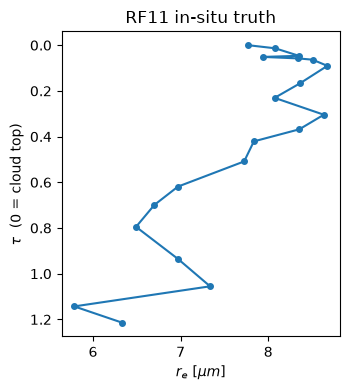

In [5]:
import jax
jax.clear_caches()   # free the intro cells' compiled executables before the (memory-heavy) retrieval

import vocals_io as vio
import retrieval_oe as roe
from miejax_lite import mie_legendre_precompute, build_re_table, select_channel

DATA = ('/home/jovyan/cloud_profile_retrieval/'
        'multispectral-retrieval-using-MODIS/VOCALS_REx_data')
profiles = vio.load_all_profiles(DATA)
truth = vio.pick_profile(profiles, target_tau=1.0)

# Leave-one-flight-out climatology: the prior NEVER sees the target's own flight.
clim = vio.vocals_climatology(profiles, exclude_flight=truth.flight)
assert truth.flight not in clim['flights'], 'LEAK: target flight in climatology'
print(f'{truth.flight}: tau_bot={truth.tau_bot:.2f}, r_base={truth.r_base:.2f}, '
      f'r_top={truth.r_top:.2f}, r_e {truth.r_e.min():.1f}-{truth.r_e.max():.1f} um')
print(f'LOO climatology (n={clim["n"]} profiles, {truth.flight} held out): '
      f'r_top={clim["r_top_mean"]:.1f}+-{clim["r_top_std"]:.1f}, '
      f'r_base={clim["r_base_mean"]:.1f}+-{clim["r_base_std"]:.1f}, '
      f'tau_bot={clim["tau_bot_mean"]:.1f}+-{clim["tau_bot_std"]:.1f}')

fig, ax = plt.subplots(figsize=(3.6, 4))
ax.plot(truth.r_e, truth.tau, 'o-', ms=4)
ax.invert_yaxis()
ax.set_xlabel(r'$r_e\ [\mu m]$'); ax.set_ylabel(r'$\tau$  (0 = cloud top)')
ax.set_title(f'{truth.flight} in-situ truth')
plt.tight_layout()

In [6]:
# --- shared diagnostics + UQ-presentation helpers (thin AND thick) -----------
# The joint state is x = [r_e(nodes), r_base, tau_bot]; post.error / data_fraction
# carry one entry per element. These helpers decode that layout for display.

def dofs_sentence(post, m, dby):
    rb = dby['r_base']
    rb_txt = ('r_base is radiatively shielded -- the prior fills it' if rb < 0.4 else
              f'r_base is partly resolved ({rb:.2f} DOF: a thin base is optically visible)')
    return (f"DOFS = {post.dofs:.2f} from {m} radiances: ~{post.dofs:.1f} independent "
            f"features, split profile={dby['profile']:.2f} / r_base={dby['r_base']:.2f} "
            f"/ tau_bot={dby['tau_bot']:.2f}. tau_bot is ~fully measured (~1 DOF); "
            f"{rb_txt}; the rest resolves the upper-cloud r_e(tau) shape.")


def joint_summary(fwd, res, post, truth, clim, sig_tau):
    # Headline joint result: retrieved tau_bot / r_base vs truth, with prior and
    # posterior 1-sigma, and the profile RMSE on the retrieved grid.
    k = len(res.tau_nodes)
    _, r_base_ret, tau_bot_ret = fwd._split_state(res.x, res.tau_nodes)
    r_base_ret, tau_bot_ret = float(r_base_ret), float(tau_bot_ret)
    rb_err, tb_err = float(post.error[k]), float(post.error[k + 1])
    rb_prior, tb_prior = float(res.x_a[k]), float(res.x_a[k + 1])   # prior MEANS used
    s = np.asarray(res.tau_nodes)
    truth_at = np.interp(s * tau_bot_ret, truth.tau, truth.r_e)
    rmse = float(np.sqrt(np.mean((np.asarray(res.x[:k]) - truth_at) ** 2)))
    rb_frac = float(post.data_fraction[k])     # 1 - Shat_ii/Sa_ii for r_base
    rb_tag = ('shielded' if rb_frac < 0.4 else 'partly shielded'
              if rb_frac < 0.7 else 'well-constrained')
    print(f'  tau_bot : retrieved {tau_bot_ret:6.2f}  truth {truth.tau_bot:6.2f}  '
          f'(prior {tb_prior:.1f}+-{sig_tau:.1f} -> post +-{tb_err:.2f})')
    print(f'  r_base  : retrieved {r_base_ret:6.2f}  truth {truth.r_base:6.2f}  '
          f'(prior {rb_prior:.1f} -> post +-{rb_err:.2f}, {rb_frac * 100:.0f}% '
          f'var.-reduction: {rb_tag})')
    print(f'  profile : RMSE {rmse:.2f} um on {k} nodes  '
          f'(ret {np.round(np.asarray(res.x[:k]), 2)} vs truth {np.round(truth_at, 2)})')


def plot_uq(fwd, res, post, truth, title=""):
    # Joint-retrieval UQ: (0) retrieved vs in-situ truth in absolute tau, with the
    # retrieved base (now an UNKNOWN, with error bars) and the prior's own tau_bot;
    # (1) per-element fraction of prior uncertainty the measurement removed, incl.
    # r_base and tau_bot; (2) profile-node averaging kernels.
    k = len(res.tau_nodes)
    s = np.asarray(res.tau_nodes)
    _, r_base_ret, tau_bot_ret = fwd._split_state(res.x, s)
    r_base_ret, tau_bot_ret = float(r_base_ret), float(tau_bot_ret)
    tau_bot_pr = float(fwd._split_state(res.x_a, s)[2])
    err = post.error
    re_err, rb_err, tb_err = err[:k], float(err[k]), float(err[k + 1])

    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))

    # panel 0: profiles in ABSOLUTE optical depth (prior drawn on its OWN tau_bot)
    tau_ret = np.linspace(0.0, tau_bot_ret, 200)
    tau_pr = np.linspace(0.0, tau_bot_pr, 200)
    ax[0].plot(truth.r_e, truth.tau, '-', color='k', alpha=0.45, label='truth (in situ)')
    ax[0].plot(fwd.profile(res.x_a, s, tau_pr), tau_pr, '--', color='C1', alpha=0.7,
               label=fr'prior ($\tau_b$={tau_bot_pr:.1f})')
    ax[0].plot(fwd.profile(res.x, s, tau_ret), tau_ret, '-', color='C0', lw=2,
               label=fr'retrieved ($\tau_b$={tau_bot_ret:.2f})')
    ax[0].errorbar(np.asarray(res.x[:k]), s * tau_bot_ret, xerr=re_err, fmt='o',
                   color='C0', capsize=3)
    ax[0].errorbar([r_base_ret], [tau_bot_ret], xerr=[rb_err], yerr=[tb_err],
                   fmt='s', color='C0', capsize=4, label=r'retrieved base $\pm1\sigma$')
    ax[0].plot([truth.r_base], [truth.tau_bot], 'X', color='red', ms=12, zorder=5,
               label='truth base')
    ax[0].set_ylim(1.15 * max(tau_bot_ret, truth.tau_bot), 0)
    ax[0].set_xlabel(r'$r_e\ [\mu m]$'); ax[0].set_ylabel(r'$\tau$')
    ax[0].legend(fontsize=8); ax[0].set_title('retrieved vs in-situ truth')

    # panel 1: per-element measurement-vs-prior split (incl r_base, tau_bot)
    meas = np.clip(post.data_fraction, 0.0, 1.0)
    labels = [fr'$s$={si:.2f}' for si in s] + [r'$r_{base}$', r'$\tau_{bot}$']
    yld = np.arange(len(meas))
    ax[1].barh(yld, meas, color='C0', label='from measurement')
    ax[1].barh(yld, 1 - meas, left=meas, color='0.82', label='from prior')
    for i, f in enumerate(meas):
        ax[1].text(0.5, i, f'{f * 100:.0f}% meas', va='center', ha='center', fontsize=8)
    ax[1].set_yticks(yld); ax[1].set_yticklabels(labels)
    ax[1].invert_yaxis(); ax[1].set_xlim(0, 1)
    ax[1].set_xlabel('fraction of prior uncertainty removed')
    ax[1].legend(fontsize=8, loc='lower right')
    ax[1].set_title('where each value comes from')

    # panel 2: averaging kernels for the profile nodes (profile block only)
    for i in range(k):
        ax[2].plot(post.A[i][:k], s, 'o-', label=fr'$s$={s[i]:.2f}')
    ax[2].invert_yaxis()
    ax[2].set_xlabel('averaging-kernel row (profile block)')
    ax[2].set_ylabel(r'normalized depth $s$')
    ax[2].legend(fontsize=7); ax[2].set_title('averaging kernels (expert)')
    fig.suptitle(title, fontsize=11); plt.tight_layout()

## 6. Multi-band, multi-angle joint forward model

A weak-to-strong **absorption ladder** (1.24 $\to$ 2.13 µm) carries the
$r_e$-vertical information; multiple **view angles** in the principal plane add
angular leverage. The forward is built in **joint mode**
(`retrieve_tau_bot=True, retrieve_r_base=True`), so $\tau_{\rm bot}$ and
$r_{\rm base}$ are read from the state and differentiated through; the constructor's
`tau_bot` / `r_base` now supply only the **leak-free climatological first guess**.
We pick the azimuthal mode count per band from the noise floor (the
$S_\varepsilon$ selector) up front so the solver compiles once.

In [7]:
bands = [1.24, 2.13]                         # weak -> strong absorption ladder
NQuad, NLeg_all, v_eff = 16, 128, 0.10
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)
table = build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp, n_radii=600)
opt_bands = [select_channel(table, i) for i in range(len(bands))]

mu0, I0, phi0 = 0.6, 1.0, 0.0
view_mu = np.array([0.90, 0.65, 0.50])      # ~25, 50, 60 deg view zenith
view_phi = np.array([pi, pi, pi])           # principal plane, back-scatter
BDRF = [[0.06]] * len(bands)                 # dark ocean (Lambertian albedo 0.06)

# Broad weakly-informative prior parameters (Option 2, the headline): generic
# marine-Sc means, NOT the truth. sigma_tau_bot ~ 50% of the mean (broad).
BROAD = dict(r_top_prior=10.0, r_base_prior=12.0, sigma_top=5.0, sigma_base=8.0)
sig_tau = 0.5 * clim['tau_bot_mean']

fwd = roe.RetrievalForward(
    opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=clim['tau_bot_mean'], r_base=clim['r_base_mean'],   # leak-free first guess
    view_mu=view_mu, view_phi=view_phi, BDRF_bands=BDRF, NLeg_all=NLeg_all,
    retrieve_tau_bot=True, retrieve_r_base=True)

# S_eps mode count at the broad first guess on a coarse NORMALIZED grid.
s_ref = np.linspace(0.0, 1.0, 5)[:-1]
x_ref, _ = roe.make_joint_prior(s_ref, tau_bot_prior=clim['tau_bot_mean'],
                                sigma_tau_bot=sig_tau, **BROAD)
K = roe.select_num_modes(fwd, x_ref, s_ref, (0.005 ** 2) * np.eye(fwd.m))
print(f'{len(bands)} bands x {view_mu.size} angles = {fwd.m} observations; '
      f'S_eps-selected modes K={K}')

2 bands x 3 angles = 6 observations; S_eps-selected modes K=[8, 8]


## 7. OSSE observation $y = F(x_{\rm true})$

We generate a **noiseless** synthetic observation by running the forward on the dense
in-situ truth profile (an Observing System Simulation Experiment). In joint mode
`osse_observation` builds the truth state at the truth's own normalized depths and
appends the truth $\tau_{\rm bot}$ / $r_{\rm base}$ — this *defines the synthetic
world*, **not** a leak (the leak would be telling the *retrieval*, whose prior and
first guess come only from the held-out climatology). Noise is deferred by design
(toward operational PACE data); the assumed $S_\varepsilon$ still weights the cost
and sets the posterior.

In [8]:
y = roe.osse_observation(fwd, truth.tau, truth.r_e)        # noiseless joint OSSE
Se = np.diag((0.03 * np.maximum(np.abs(y), 0.02)) ** 2)    # ~3% radiometric + floor
print('observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]')
print(np.round(y.reshape(len(bands), view_mu.size), 4))
assert np.all(y > 0), 'unphysical (negative) reflectance'

observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]
[[0.1442 0.2787 0.2771]
 [0.1383 0.2472 0.3068]]


## 8. Retrieval grid (normalized depth) + how many nodes? (SO1)

The retrieval grid is the QRCP-ranked, sensitivity-selected subset of the solver's
own adaptive $\tau$-pool (`DESIGN_DECISIONS.md` §3), now expressed in **normalized
depth** $s=\tau/\tau_{\rm bot}$ so it is invariant to the retrieved $\tau_{\rm bot}$.
**SO1 — how many nodes can the data support?** `auto_k_active` offers two independent
estimators: the user's $k=\text{round}(\text{factor}\cdot\text{DOFS})$ and a
noise-aware whitened-QRCP **filter-factor** count (*not* via DOFS). Their agreement
($\Sigma f_i\approx$ DOFS) is a built-in robustness check on DOFS itself.

In [9]:
s_coarse = np.linspace(0.0, 1.0, 6)[:-1]                  # coarse normalized first-guess grid
x_fg, _ = roe.make_joint_prior(s_coarse, tau_bot_prior=clim['tau_bot_mean'],
                               sigma_tau_bot=sig_tau, **BROAD)
k_active = 4
s_grid, _, info = roe.select_retrieval_grid(fwd, x_fg, s_coarse, k_active)
print(f'ODE pool: {info["s_pool"].size} nodes -> QRCP-selected {k_active} in s = '
      f'{np.round(s_grid, 3)}')

# SO1: what would auto_k_active pick? (profile-only pool Jacobian, no extra compile)
Sa_pool = roe.make_adiabatic_prior(info['s_pool'], 1.0, clim['r_base_mean'],
                                   BROAD['r_top_prior'], sigma_top=BROAD['sigma_top'],
                                   sigma_base=BROAD['sigma_base'])[1]
k_f, if_f = roe.auto_k_active(info['K_pool'], Se, Sa_pool, method='filter')
k_d, if_d = roe.auto_k_active(info['K_pool'], Se, Sa_pool, method='dofs', factor=1.5)
agree = abs(if_f['sum_filter_factor'] - if_f['dofs']) / if_f['dofs'] * 100
print(f"SO1 auto_k: filter -> {k_f} (Sum f_i={if_f['sum_filter_factor']:.2f}, "
      f"data-dominated={if_f['n_data_dominated']}), dofs -> {k_d} "
      f"(DOFS={if_d['dofs']:.2f})")
print(f"   Sum f_i vs DOFS agree to {agree:.0f}% -> DOFS is a robust info measure here")

ODE pool: 20 nodes -> QRCP-selected 4 in s = [0.    0.048 0.161 0.494]
SO1 auto_k: filter -> 4 (Sum f_i=3.01, data-dominated=3), dofs -> 4 (DOFS=2.88)
   Sum f_i vs DOFS agree to 5% -> DOFS is a robust info measure here


## 9. Prior: broad weakly-informative joint prior (Option 2)

The headline prior is **broad / weakly-informative**: generic marine-Sc means
(`make_joint_prior`) with wide $\sigma$ — the data set $\tau_{\rm bot}$ and the
upper-cloud $r_e$; the prior only fills the shielded base. $r_{\rm base}$ joins the
correlated $r_e$ block as the deepest node (it *is* $r_e$ at the base); $\tau_{\rm bot}$
is an independent broad scalar. The tighter **LOO climatology** prior
(`make_climatology_prior`) is the recorded fallback (`DESIGN_DECISIONS.md` §10b).

In [10]:
prior_builder = lambda sn: roe.make_joint_prior(
    sn, tau_bot_prior=clim['tau_bot_mean'], sigma_tau_bot=sig_tau, **BROAD)
x_a, Sa = prior_builder(s_grid)
print('prior x_a    =', np.round(x_a, 2), '  [r_e nodes, r_base, tau_bot]')
print('prior sigma  =', np.round(np.sqrt(np.diag(Sa)), 1), '  (tau_bot is the last)')

prior x_a    = [10.   10.14 10.44 11.16 12.   10.59]   [r_e nodes, r_base, tau_bot]
prior sigma  = [5.  5.1 5.5 6.5 8.  5.3]   (tau_bot is the last)


## 10. Optimal estimation with a structural-misfit re-mesh gate (SO2b)

Rodgers Gauss–Newton minimises
$J(x)=\tfrac12\|y-F(x)\|^2_{S_\varepsilon^{-1}}+\tfrac12\|x-x_a\|^2_{S_a^{-1}}$ with
the exact reverse-mode Jacobian and **projected steps** (each iterate is clamped to
the optics table and physical $\tau_{\rm bot}$ bounds, `DESIGN` §10a). **SO2b:** the
outer re-mesh loop is *gated* on a persistently high reduced-$\chi^2$
(`remesh_if_chi2_red_gt`) — re-mesh only when the fit signals a structural error,
not when a well-fit but correlated node basis would just churn placement. With
`n_outer=2` and a good fit the gate keeps it effectively select-once.

In [11]:
res = roe.gauss_newton_oe(
    fwd, y, s_grid, x_a, Sa, Se, n_iter=12, lm=1e-2, xtol=2e-3,
    n_outer=2, k_active=k_active, prior_builder=prior_builder,
    remesh_if_chi2_red_gt=2.0)
remeshed = not (len(res.tau_nodes) == len(s_grid)
                and np.allclose(res.tau_nodes, s_grid, atol=1e-3))
print(f'converged={res.converged}, '
      f'cost {res.cost_history[0]:.2e} -> {res.cost_history[-1]:.2e}, '
      f'||y-F|| = {np.linalg.norm(res.y - res.Fx):.2e}')
print(f'final grid s = {np.round(res.tau_nodes, 3)}  '
      f'(re-mesh {"applied" if remeshed else "skipped by chi2 gate -- fit at noise floor"})')

converged=False, cost 8.26e+03 -> 1.85e+00, ||y-F|| = 9.95e-04
final grid s = [0.    0.048 0.161 0.494]  (re-mesh skipped by chi2 gate -- fit at noise floor)


## 11. Uncertainty quantification — and the PO answer

The posterior $\hat S=(K^{\!\top}S_\varepsilon^{-1}K+S_a^{-1})^{-1}$ gives per-element
$\pm1\sigma$; the averaging kernel $A=\hat S\,K^{\!\top}S_\varepsilon^{-1}K$ and
$\text{DOFS}=\text{tr}\,A$ count independent features. **`dofs_by_component` splits the
DOFS** into profile / $r_{\rm base}$ / $\tau_{\rm bot}$ — directly answering the **PO
question**: making $\tau_{\rm bot}$ unknown costs almost nothing because the
measurement supplies $\sim$1 full DOF to it (its $1\sigma$ collapses from the broad
prior to $\sim$0.05). **$r_{\rm base}$ is depth-dependent**: for this *thin* cloud the
base is optically visible, so the measurement removes $\sim$90 % of its prior variance
(DOFS $\approx$0.85) and the retrieval pulls it well off the prior toward truth — for a
*thick* cloud (§12) the same quantity is radiatively **shielded** (only $\sim$30 %
removed, posterior $\approx$ prior). The middle panel shows this per element; the
profile panel shows the prior's own (wrong) $\tau_{\rm bot}$ collapsing onto the truth
depth.

retrieval 1-sigma = [2.34 1.81 1.92 2.37 2.58 0.05]   [r_e nodes, r_base, tau_bot]
  tau_bot : retrieved   1.23  truth   1.21  (prior 10.6+-5.3 -> post +-0.05)
  r_base  : retrieved   7.67  truth   6.33  (prior 12.0 -> post +-2.58, 90% var.-reduction: well-constrained)
  profile : RMSE 0.53 um on 4 nodes  (ret [8.75 8.7  8.31 6.87] vs truth [7.77 8.37 8.22 7.05])
DOFS = 3.64 from 6 radiances: ~3.6 independent features, split profile=1.80 / r_base=0.85 / tau_bot=1.00. tau_bot is ~fully measured (~1 DOF); r_base is partly resolved (0.85 DOF: a thin base is optically visible); the rest resolves the upper-cloud r_e(tau) shape.


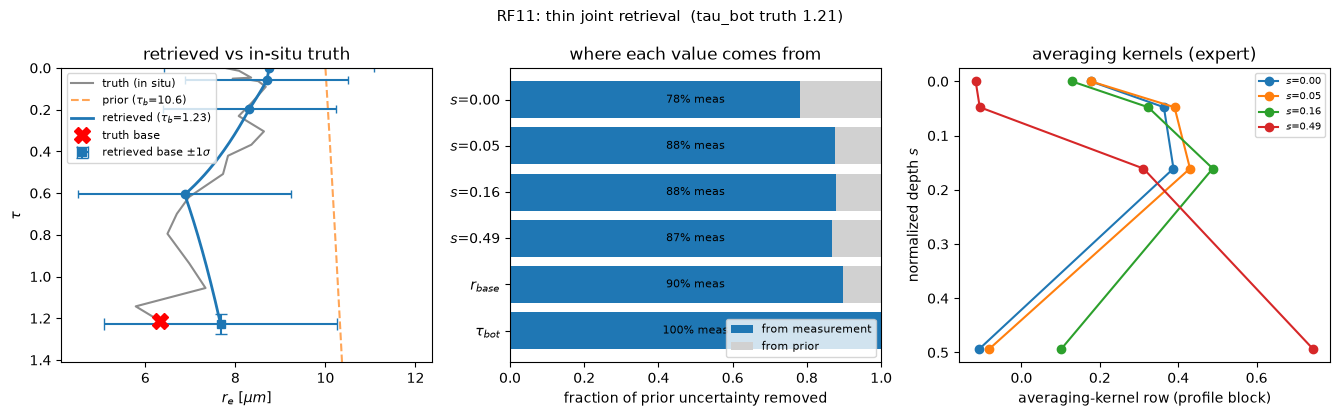

In [12]:
post = roe.posterior_diagnostics(res.K, res.Sa, res.Se)
dby = roe.dofs_by_component(post, len(res.tau_nodes),
                            retrieve_r_base=True, retrieve_tau_bot=True)
print('retrieval 1-sigma =', np.round(post.error, 2), '  [r_e nodes, r_base, tau_bot]')
joint_summary(fwd, res, post, truth, clim, sig_tau)
print(dofs_sentence(post, fwd.m, dby))
_ = plot_uq(fwd, res, post, truth,
            title=f'{truth.flight}: thin joint retrieval  (tau_bot truth {truth.tau_bot:.2f})')

## 12. A thick, non-adiabatic cloud ($\tau\approx23$) — joint retrieval

VOCALS-REx **RF03** ($\tau_{\rm bot}\!\approx\!23$) is genuinely non-adiabatic and,
unlike the thin case, the prior is *wrong about the depth*: the LOO climatology
$\tau_{\rm bot}$ prior ($\approx10$) is less than half the truth. The joint retrieval
must **pull $\tau_{\rm bot}$ up** from $\sim$10 to $\sim$21 (truth 23.3) purely from
the multi-band reflectance, while recovering the upper-cloud $r_e$ that runs
$\sim$1.5–2 µm below adiabatic. We add a third band (**1.64 µm**) for vertical
leverage and keep everything else: the $r_e^5$-linear class, the normalized-depth
QRCP grid, the broad joint prior, the $S_\varepsilon$ mode selector. The base
($\tau\gtrsim$ a few) is optically shielded, so its $r_e$ stays prior-dominated. We
select the grid **once** ($n_{\rm outer}=1$): the thin section already exercised the
gated re-mesh.

In [13]:
import jax
jax.clear_caches()   # free the thin retrieval's executables before the thicker solve

thick = vio.pick_profile([p for p in profiles if p.flight == 'RF03'], target_tau=23.3)
climT = vio.vocals_climatology(profiles, exclude_flight=thick.flight)
print(f'{thick.flight}: tau_bot={thick.tau_bot:.1f}, r_base={thick.r_base:.2f}, '
      f'r_e {thick.r_e.min():.1f}-{thick.r_e.max():.1f} um (n={thick.tau.size})')
print(f'LOO climatology tau_bot prior = {climT["tau_bot_mean"]:.1f}+-{climT["tau_bot_std"]:.1f} '
      f'(truth {thick.tau_bot:.1f} -- the prior under-shoots the depth ~2x)')

bandsT = [1.24, 1.64, 2.13]                   # weak -> strong absorption ladder (+1.64)
opt_bandsT = [select_channel(build_re_table(bandsT, 2.0, 25.0, 32, v_eff, precomp,
                                            n_radii=600), i)
              for i in range(len(bandsT))]
BDRFt = [[0.06]] * len(bandsT)
sig_tauT = 0.5 * climT['tau_bot_mean']

fwdT = roe.RetrievalForward(
    opt_bandsT, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=climT['tau_bot_mean'], r_base=climT['r_base_mean'],
    view_mu=view_mu, view_phi=view_phi, BDRF_bands=BDRFt, NLeg_all=NLeg_all,
    retrieve_tau_bot=True, retrieve_r_base=True)

s_refT = np.linspace(0.0, 1.0, 6)[:-1]
x_refT, _ = roe.make_joint_prior(s_refT, tau_bot_prior=climT['tau_bot_mean'],
                                 sigma_tau_bot=sig_tauT, **BROAD)
KT = roe.select_num_modes(fwdT, x_refT, s_refT, (0.005 ** 2) * np.eye(fwdT.m))
yT = roe.osse_observation(fwdT, thick.tau, thick.r_e)
SeT = np.diag((0.03 * np.maximum(np.abs(yT), 0.02)) ** 2)
assert np.all(yT > 0), 'unphysical (negative) reflectance'

k_activeT = 5
s_gridT, _, infoT = roe.select_retrieval_grid(fwdT, x_refT, s_refT, k_activeT)
Sa_poolT = roe.make_adiabatic_prior(infoT['s_pool'], 1.0, climT['r_base_mean'],
                                    BROAD['r_top_prior'], sigma_top=BROAD['sigma_top'],
                                    sigma_base=BROAD['sigma_base'])[1]
k_fT, if_fT = roe.auto_k_active(infoT['K_pool'], SeT, Sa_poolT, method='filter')
k_dT, if_dT = roe.auto_k_active(infoT['K_pool'], SeT, Sa_poolT, method='dofs', factor=1.5)
print(f'{len(bandsT)} bands x {view_mu.size} angles = {fwdT.m} obs; modes K={KT}')
print(f'QRCP-selected {k_activeT} nodes in s = {np.round(s_gridT, 3)}')
print(f"SO1 auto_k: filter -> {k_fT} (data-dominated {if_fT['n_data_dominated']}), "
      f"dofs -> {k_dT} (DOFS={if_dT['dofs']:.2f}); filter is the conservative choice "
      f"under thick-cloud saturation")

RF03: tau_bot=23.3, r_base=6.45, r_e 5.5-11.4 um (n=109)
LOO climatology tau_bot prior = 10.2+-9.8 (truth 23.3 -- the prior under-shoots the depth ~2x)


3 bands x 3 angles = 9 obs; modes K=[8, 8, 8]
QRCP-selected 5 nodes in s = [0.    0.041 0.151 0.32  0.479]
SO1 auto_k: filter -> 3 (data-dominated 2), dofs -> 4 (DOFS=2.39); filter is the conservative choice under thick-cloud saturation


cost 1.65e+02 -> 3.12e+00, ||y-F|| = 8.28e-03  (measurement corrects the prior)
  tau_bot : retrieved  20.95  truth  23.26  (prior 10.2+-5.1 -> post +-0.64)
  r_base  : retrieved   5.15  truth   6.45  (prior 12.0 -> post +-6.73, 29% var.-reduction: shielded)
  profile : RMSE 0.86 um on 5 nodes  (ret [10.88 10.84  9.53  8.14  7.24] vs truth [11.41  9.54  9.55  8.81  8.38])
DOFS = 3.46 from 9 radiances: ~3.5 independent features, split profile=2.30 / r_base=0.17 / tau_bot=0.98. tau_bot is ~fully measured (~1 DOF); r_base is radiatively shielded -- the prior fills it; the rest resolves the upper-cloud r_e(tau) shape.


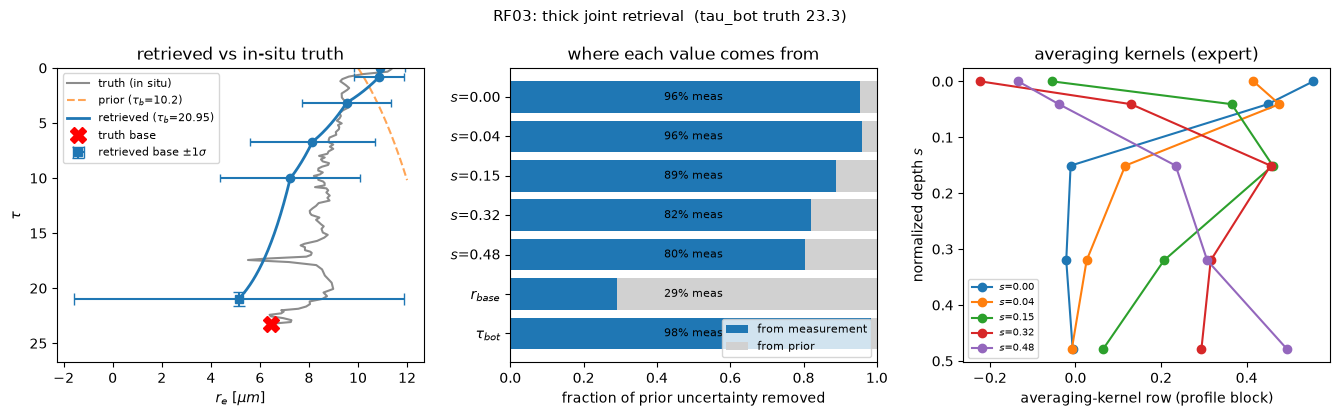

In [14]:
prior_builderT = lambda sn: roe.make_joint_prior(
    sn, tau_bot_prior=climT['tau_bot_mean'], sigma_tau_bot=sig_tauT, **BROAD)
x_aT, SaT = prior_builderT(s_gridT)

# Select the grid once (n_outer=1): with only ~2-3 profile DOF the deep nodes are
# correlated; the thin section showed the gated re-mesh. xtol ~ 0.05 um step scale.
resT = roe.gauss_newton_oe(fwdT, yT, s_gridT, x_aT, SaT, SeT,
                           n_iter=15, lm=1e-2, xtol=5e-3, n_outer=1)
postT = roe.posterior_diagnostics(resT.K, resT.Sa, resT.Se)
dbyT = roe.dofs_by_component(postT, len(resT.tau_nodes),
                             retrieve_r_base=True, retrieve_tau_bot=True)
print(f'cost {resT.cost_history[0]:.2e} -> {resT.cost_history[-1]:.2e}, '
      f'||y-F|| = {np.linalg.norm(resT.y - resT.Fx):.2e}  (measurement corrects the prior)')
joint_summary(fwdT, resT, postT, thick, climT, sig_tauT)
print(dofs_sentence(postT, fwdT.m, dbyT))
_ = plot_uq(fwdT, resT, postT, thick,
            title=f'{thick.flight}: thick joint retrieval  (tau_bot truth {thick.tau_bot:.1f})')

## 13. Can reflectance recover a sub-adiabatic (re-evaporating) base?

§11–§12 showed the cloud base is a **depth-dependent blind spot**: for the thin RF11
the base was $\sim$90 % measured (r_base pulled from the adiabatic prior 12 → 7.7,
truth 6.3), but for the thick RF03 it was shielded. A *sub-adiabatic* base — $r_e$
**dropping** toward cloud bottom — is the microphysical signature of sub-saturation /
drizzle **re-evaporation**. Starting from an **adiabatic** prior (which wants $r_e$ to
*rise* to a large base value), can the retrieval recover a *downturn*? We test two real
VOCALS thin profiles whose departure sits in different places:

* **RF14** ($\tau\!\approx\!2.5$): $r_e$ declines through the **optically visible**
  upper cloud.
* **RF05** ($\tau\!\approx\!2.9$): $r_e$ rises adiabatically then drops only in the
  **bottom $\sim$40 %** (already shielded).

The discriminator is **not $\tau$** but *where* the structure sits relative to photon
penetration. (The data floor is $\tau\!\approx\!1.2$ — no thinner clouds survive the
profile-extraction LWC threshold — so RF11 in §11 is the thinnest near-bottom case;
$\tau\!\lesssim\!1$ cannot be tested here.)

In [15]:
import jax
jax.clear_caches()   # free the thick retrieval's executables before the sub-adiabatic pair


def subadiab_retrieve(flight, target_tau, bands):
    # Joint retrieval from the BROAD ADIABATIC prior (r_base mean 12 > r_top 10, i.e.
    # the curve *wants* to rise to base) so any downturn in the result is data-driven.
    tr = vio.pick_profile([p for p in profiles if p.flight == flight], target_tau)
    cl = vio.vocals_climatology(profiles, exclude_flight=tr.flight)
    ob = [select_channel(build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp,
                                        n_radii=600), i) for i in range(len(bands))]
    st = 0.5 * cl['tau_bot_mean']
    fw = roe.RetrievalForward(ob, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
                              tau_bot=cl['tau_bot_mean'], r_base=cl['r_base_mean'],
                              view_mu=view_mu, view_phi=view_phi,
                              BDRF_bands=[[0.06]] * len(bands), NLeg_all=NLeg_all,
                              retrieve_tau_bot=True, retrieve_r_base=True)
    yy = roe.osse_observation(fw, tr.tau, tr.r_e)
    Se_ = np.diag((0.03 * np.maximum(np.abs(yy), 0.02)) ** 2)
    sref = np.linspace(0.0, 1.0, 6)[:-1]
    xr, _ = roe.make_joint_prior(sref, tau_bot_prior=cl['tau_bot_mean'],
                                 sigma_tau_bot=st, **BROAD)
    roe.select_num_modes(fw, xr, sref, Se_)
    sg, _, _ = roe.select_retrieval_grid(fw, xr, sref, 5)
    pb = lambda sn: roe.make_joint_prior(sn, tau_bot_prior=cl['tau_bot_mean'],
                                         sigma_tau_bot=st, **BROAD)
    xa, Sa_ = pb(sg)
    r = roe.gauss_newton_oe(fw, yy, sg, xa, Sa_, Se_, n_iter=15, lm=1e-2, xtol=2e-3,
                            n_outer=1)
    po = roe.posterior_diagnostics(r.K, r.Sa, r.Se)
    kk = len(r.tau_nodes); s_ = np.asarray(r.tau_nodes)
    tb, rb, tb_pr = float(r.x[kk + 1]), float(r.x[kk]), float(cl['tau_bot_mean'])
    sd = np.linspace(0.0, 1.0, 200)
    ret = np.asarray(fw.profile(r.x, s_, sd * tb))
    pri = np.asarray(fw.profile(r.x_a, s_, sd * tb_pr))
    tru = np.interp(sd * tb, tr.tau, tr.r_e)
    drop_ret, drop_tru = float(ret.max() - ret[-1]), float(tru.max() - tru[-1])
    cap = drop_ret / drop_tru if drop_tru > 1e-9 else float('nan')
    return dict(tr=tr, tb=tb, tb_pr=tb_pr, rb=rb, rb_err=float(po.error[kk]),
                sd=sd, ret=ret, pri=pri, drop_ret=drop_ret, drop_tru=drop_tru, cap=cap,
                dofs_rbase=roe.dofs_by_component(po, kk, retrieve_r_base=True,
                                                 retrieve_tau_bot=True)['r_base'])


SUB = {f: subadiab_retrieve(f, t, [1.24, 1.64, 2.13])
       for f, t in [('RF14', 2.46), ('RF05', 2.88)]}
for f, R in SUB.items():
    v = 'CAPTURED' if R['drop_ret'] > 0.3 and R['cap'] > 0.3 else 'MISSED (prior won)'
    print(f"{f} tau_bot={R['tr'].tau_bot:.2f}: downturn truth {R['drop_tru']:+.2f} um, "
          f"retrieved {R['drop_ret']:+.2f} um ({R['cap'] * 100:.0f}% captured) -> {v}")
    print(f"     r_base 12.0(prior) -> {R['rb']:.1f}(ret), truth {R['tr'].r_base:.1f}; "
          f"DOFS r_base={R['dofs_rbase']:.2f}")

RF14 tau_bot=2.46: downturn truth +3.40 um, retrieved +1.63 um (48% captured) -> CAPTURED
     r_base 12.0(prior) -> 7.6(ret), truth 6.0; DOFS r_base=0.62
RF05 tau_bot=2.88: downturn truth +2.09 um, retrieved +0.00 um (0% captured) -> MISSED (prior won)
     r_base 12.0(prior) -> 9.6(ret), truth 6.8; DOFS r_base=0.35


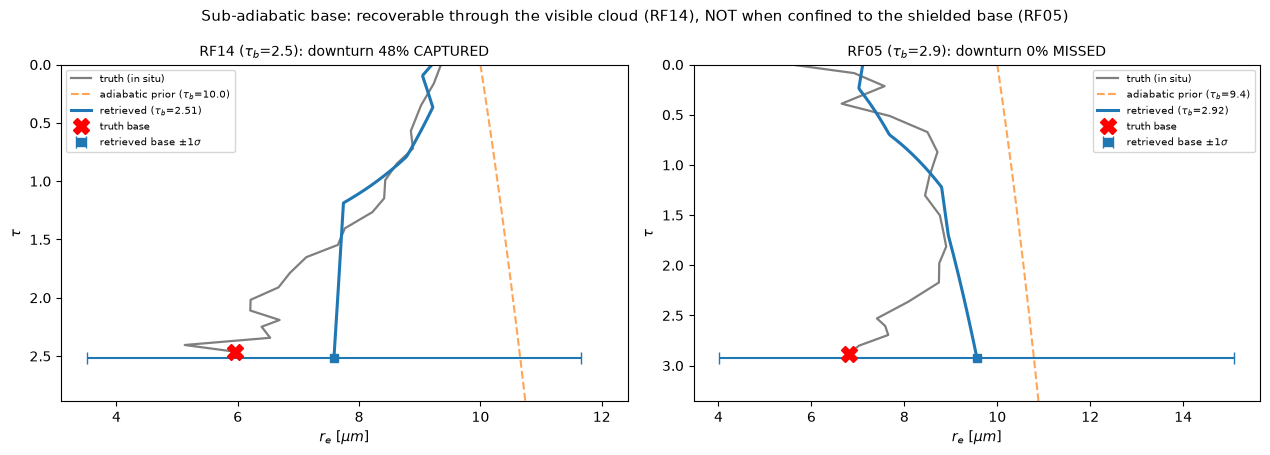

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
for ax, (f, R) in zip(axes, SUB.items()):
    tr = R['tr']
    ax.plot(tr.r_e, tr.tau, '-', color='k', alpha=0.5, lw=1.6, label='truth (in situ)')
    ax.plot(R['pri'], R['sd'] * R['tb_pr'], '--', color='C1', alpha=0.7,
            label=fr"adiabatic prior ($\tau_b$={R['tb_pr']:.1f})")
    ax.plot(R['ret'], R['sd'] * R['tb'], '-', color='C0', lw=2.2,
            label=fr"retrieved ($\tau_b$={R['tb']:.2f})")
    ax.errorbar([R['rb']], [R['tb']], xerr=[R['rb_err']], fmt='s', color='C0',
                capsize=4, label=r'retrieved base $\pm1\sigma$')
    ax.plot([tr.r_base], [tr.tau_bot], 'X', color='red', ms=12, zorder=5,
            label='truth base')
    ax.set_ylim(1.15 * max(R['tb'], tr.tau_bot), 0)
    ax.set_xlabel(r'$r_e\ [\mu m]$'); ax.set_ylabel(r'$\tau$')
    v = 'CAPTURED' if R['drop_ret'] > 0.3 and R['cap'] > 0.3 else 'MISSED'
    ax.set_title(f"{f} ($\\tau_b$={tr.tau_bot:.1f}): downturn "
                 f"{R['cap'] * 100:.0f}% {v}", fontsize=10)
    ax.legend(fontsize=7.5)
fig.suptitle('Sub-adiabatic base: recoverable through the visible cloud (RF14), '
             'NOT when confined to the shielded base (RF05)', fontsize=11)
plt.tight_layout()

## 14. Synthesis — answers to the retrieval questions

**PO (joint base + depth; prior-dependent DOFS).** Making
$(\tau_{\rm bot},\,r_{\rm base})$ unknown is *cheap*: the multi-band reflectance pins
$\tau_{\rm bot}$ to $\sim$1 full DOF (retrieved 1.23 vs 1.21 thin; 21 vs 23 thick,
from a leak-free prior of $\sim$10). $r_{\rm base}$ is **depth-dependent, not uniformly
shielded**: optically visible (90 % measured) for the thin cloud, radiatively shielded
(30 %) for the thick. DOFS is **prior-dependent** — the broad prior yields a higher
*marginal* DOFS than the tighter climatology (it pre-supplies less), so DOFS must be
reported against its prior. A **conservative band is not worth swapping in** (it
saturates for thick cloud); keep the weak-absorber ladder. **Joint > two-stage:** the
inversion already nails $\tau_{\rm bot}$ and propagates its uncertainty into the $r_e$
posterior. (`DESIGN_DECISIONS.md` §10.)

**Sub-adiabatic base (§13).** Following from the depth-dependent $r_{\rm base}$: a
re-evaporation downturn is recoverable **only where the cloud is optically visible** —
captured for RF14 (decline through the upper cloud) but **missed** for RF05 (drop
confined to the shielded bottom 40 %), despite near-equal $\tau$. The discriminator is
*where the structure sits*, not $\tau$; and the $\tau\!\approx\!1.2$ data floor means
$\tau\!\lesssim\!1$ cannot be probed. (`DESIGN_DECISIONS.md` §10c.)

**SO1 (node count / DOFS robustness).** $\Sigma f_i$ (whitened-QRCP filter factors,
*independent* of DOFS) tracks DOFS to $\sim$5 % in both cases above — **DOFS is an
accurate, robust information measure here**. The two node-count estimators agree on
thin (4/4) and differ by one on thick (filter 3 / dofs 4); the filter count is
preferred (no arbitrary factor, integer, conservative under saturation).

**SO2a (interpolation lever).** Across the OSSE matrix
(`docs/joint_osse_results.json`), $r_e^5$-linear beats plain-linear on profile RMSE by
**$<0.1$ µm** — within the retrieval's own uncertainty. As anticipated, for reasonable
low-order monotonic interpolation the choice is a **second-order lever**; $r_e^5$-linear
is kept on physical grounds (adiabatic $r_e\propto\tau^{1/5}$). (`OUTSTANDING.md` §B′.)

**SO2b (re-meshing).** $n_{\rm outer}=2$ did **not** help the thin case (RMSE
$0.53\to0.70$ µm at unchanged fit) — re-pivoting a well-fit correlated basis just
churns placement. The $\chi^2$ gate above is the right policy: re-mesh only on a
persistently high loss (structural misfit). (`OUTSTANDING.md` §G.)